# CNN From Scratch: Garment Classifier

Custom CNN architecture (no transfer learning) trained on 14 garment
categories, compared against a fine-tuned ViT (see `04A`/`04B`).

This notebook rewrites the architecture from `03_..._secuential.ipynb`
(personal reference notebook, not in this repo) as a proper `nn.Module`
subclass with an explicit `forward()` — the same validated design, in the
idiomatic PyTorch pattern used in most real projects.

## 0. Environment setup

Edit the two values below, then **Run All**. Works locally (CPU) or in
Google Colab (GPU) without touching anything else in the notebook.

In [1]:
# ENVIRONMENT SETUP 
RUNTIME = "local"     # "colab" or "local"
DEVICE  = "auto"      # "auto", "gpu", or "cpu"

In [2]:
import os
import torch

if RUNTIME == "colab":
    from google.colab import drive
    drive.mount('/content/drive')
    !pip install -q torch torchvision scikit-learn matplotlib seaborn

    PROJECT_ROOT = "/content/drive/MyDrive/CNN/wardrove-selector"
elif RUNTIME == "local":
    PROJECT_ROOT = ".."
else:
    raise ValueError(f"Unknown RUNTIME: {RUNTIME!r} (expected 'colab' or 'local')")

import sys
sys.path.append(f"{PROJECT_ROOT}/src")

if DEVICE == "auto":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
elif DEVICE == "gpu":
    if not torch.cuda.is_available():
        raise RuntimeError("DEVICE='gpu' was requested but no GPU is available in this runtime.")
    device = torch.device('cuda')
elif DEVICE == "cpu":
    device = torch.device('cpu')
else:
    raise ValueError(f"Unknown DEVICE: {DEVICE!r} (expected 'auto', 'gpu', or 'cpu')")

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"device       = {device}")

PROJECT_ROOT = ..
device       = cpu


## 1. Load data

In [3]:
from data import get_dataloaders

train_loader, val_loader, test_loader = get_dataloaders(batch_size=32)

images, labels = next(iter(train_loader))
print(images.shape, labels.shape)

torch.Size([32, 3, 224, 224]) torch.Size([32])


## 2. Create model

In [4]:
import torch.nn as nn

class GarmentCNN(nn.Module):
    def __init__(self, num_classes=14):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding='same'),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding='same'),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding='same'),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.block4 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding='same'),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.block5 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding='same'),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(256, num_classes)


    def forward(self, x):

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)

        x = self.gap(x)
        x = x.flatten(1)   # tensor op, not a layer -- no learnable params, so it doesn't belong in __init__
        x = self.dropout(x)
        x = self.classifier(x)

        return x

In [5]:
model = GarmentCNN().to(device)

model.eval()
with torch.no_grad():
    outputs = model(images.to(device))

print("Output:", outputs.shape)

Output: torch.Size([32, 14])


## 3. Create Training Loop

In [6]:
import torch.nn.functional as F

def train(model,optimizer, train_loader, val_loader, device, epochs=20):

    train_loss_history = [] #Train loss per epoch
    val_loss_history = [] #Val loss per epoch

    best_val_loss = float('inf') # Saves the model with the lowest validation loss (the best model)
    
    for epoch_index in range(epochs):

        # TRAIN
        model.train()

        train_running_loss = 0.0 # Sum of the loss of each batch within this epoch
        train_num_batches = 0 # How many batches were summed, to be able to average at the end

        # Runs over each batch from the training set

        for batch_inputs, batch_labels in train_loader:

            batch_inputs = batch_inputs.to(device=device, dtype=torch.float32)
            batch_labels = batch_labels.to(device=device, dtype=torch.long)

            # Forward pass

            logits = model(batch_inputs)

            # Loss function

            loss = F.cross_entropy(logits,batch_labels)

            # Backpropagation

            optimizer.zero_grad() # Reset gradients

            loss.backward() # Backpropagation

            # Optimizer Step (gradient descent)
            optimizer.step()
            
            # Accumilates the loss per batch
            train_running_loss += loss.item()
            train_num_batches += 1

        # Average loss of this epoch over all batches

        train_loss_epoch = train_running_loss / train_num_batches
        train_loss_history.append(train_loss_epoch)



        # VALIDATION
        model.eval()

        val_running_loss = 0.0
        val_num_batches = 0

        # Runs over each batch from the training set

        with torch.no_grad():
            for batch_inputs, batch_labels in val_loader:

                batch_inputs = batch_inputs.to(device=device, dtype=torch.float32)
                batch_labels = batch_labels.to(device=device, dtype=torch.long)

                # Forward pass

                logits = model(batch_inputs)

                # Loss function

                loss = F.cross_entropy(logits,batch_labels)

                val_running_loss += loss.item()
                val_num_batches += 1

        # Average loss of this epoch over all batches
        val_loss_epoch = val_running_loss / val_num_batches
        val_loss_history.append(val_loss_epoch)

        if val_loss_epoch < best_val_loss:
            best_val_loss = val_loss_epoch
            torch.save(model.state_dict(), 'best_model_cnn.pt')

        print(
            f"    Epoch {epoch_index+1:02d}  "
            f"    Train loss (avg): {train_loss_epoch:.6f}  "
            f"    Validation loss (avg): {val_loss_epoch:.6f}  "
        )
    
    return  train_loss_history, val_loss_history




        
        



## 4. Create Optimizer

In [7]:
optimizer = torch.optim.Adam(
    model.parameters(),  # reference to the model's trainable tensors (parameters). Adam reads/updates them via .grad
    lr=1e-3,             # Adam's typical default; its per-parameter adaptive scaling makes it less sensitive to this exact value than plain SGD
    weight_decay=1e-4,   # L2 regularization, shrinks weights slightly each step to reduce overfitting
)

## 5. Training

In [8]:
train_loss_history, val_loss_history = train(
    model, optimizer,train_loader, val_loader, device, epochs=20
)

    Epoch 01      Train loss (avg): 1.124684      Validation loss (avg): 1.194375  
    Epoch 02      Train loss (avg): 0.808055      Validation loss (avg): 0.963161  
    Epoch 03      Train loss (avg): 0.706307      Validation loss (avg): 0.778149  
    Epoch 04      Train loss (avg): 0.637574      Validation loss (avg): 0.983079  
    Epoch 05      Train loss (avg): 0.591957      Validation loss (avg): 0.809663  
    Epoch 06      Train loss (avg): 0.546230      Validation loss (avg): 1.056759  
    Epoch 07      Train loss (avg): 0.520687      Validation loss (avg): 0.783581  
    Epoch 08      Train loss (avg): 0.493904      Validation loss (avg): 1.199727  
    Epoch 09      Train loss (avg): 0.471043      Validation loss (avg): 0.626160  
    Epoch 10      Train loss (avg): 0.449709      Validation loss (avg): 0.693120  
    Epoch 11      Train loss (avg): 0.433197      Validation loss (avg): 0.588084  
    Epoch 12      Train loss (avg): 0.426945      Validation loss (avg): 0.4

## 6. Loss - Train VS Validation 

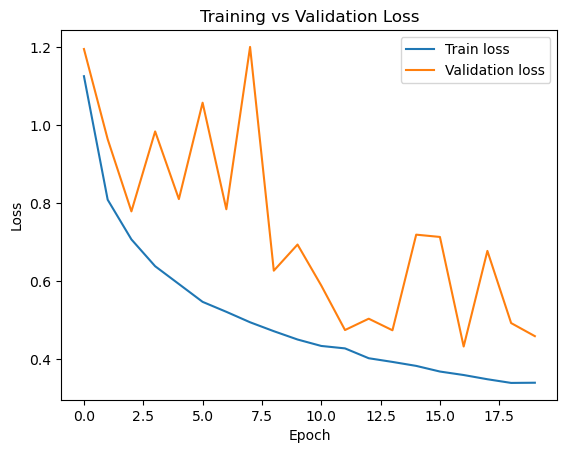

In [9]:
import matplotlib.pyplot as plt

plt.plot(train_loss_history, label='Train loss')
plt.plot(val_loss_history, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

## 7. Evaluation

In [10]:
model.load_state_dict(torch.load('best_model_cnn.pt'))

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_inputs, batch_labels in test_loader:
        batch_inputs = batch_inputs.to(device=device, dtype=torch.float32)
        batch_labels = batch_labels.to(device=device, dtype=torch.long)

        logits = model(batch_inputs)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_labels.cpu().numpy())

### 7.1 Classification Report

In [11]:
from sklearn.metrics import classification_report
from data import categories

print(classification_report(all_labels, all_preds, target_names=categories))

              precision    recall  f1-score   support

     Tshirts       0.94      0.91      0.93       707
      Shirts       0.89      0.97      0.93       322
        Tops       0.67      0.77      0.72       176
       Jeans       0.92      0.98      0.95        61
 Sweatshirts       0.78      0.25      0.38        28
    Sweaters       0.55      0.57      0.56        28
     Jackets       0.56      0.58      0.57        26
     Dresses       0.90      0.80      0.85        46
      Skirts       0.75      0.46      0.57        13
      Shorts       0.93      0.91      0.92        55
 Track Pants       0.93      0.84      0.88        31
Casual Shoes       0.80      0.90      0.85       284
Sports Shoes       0.91      0.70      0.79       203
Formal Shoes       0.81      0.92      0.86        64

    accuracy                           0.86      2044
   macro avg       0.81      0.75      0.77      2044
weighted avg       0.87      0.86      0.86      2044



### 7.2 Confusion Matrix

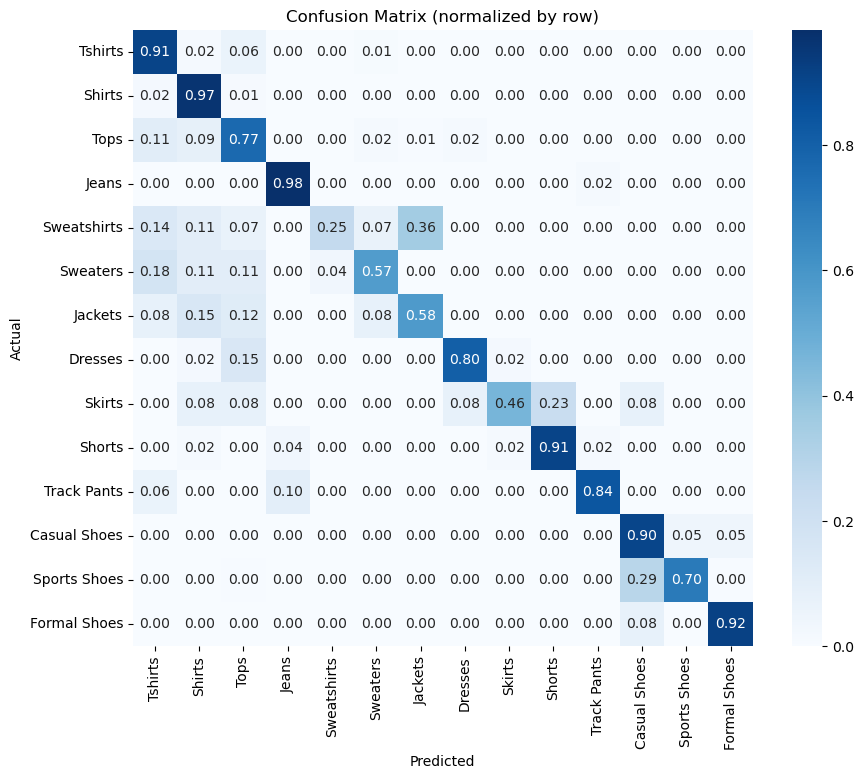

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds, normalize='true')

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', xticklabels=categories, yticklabels=categories, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (normalized by row)')
plt.show()